# CirclePack in Jupyter — Demo

This notebook shows how to drive **CirclePack** from a Jupyter notebook,
freely mixing **Markdown**, **Python**, and **CirclePack commands** in one
document.

CirclePack runs as its own GUI application. This notebook talks to it over
its command socket using the `%%circlepack` cell magic (and the
`circlepack_client` Python module) from the `cptools/` folder.

> A *circle packing* is a configuration of circles with a prescribed pattern
> of tangencies; CirclePack computes and draws them. Here we'll create a few
> and view them inline.

## Prerequisites & setup

1. **Start CirclePack with its command socket** — it starts automatically with
   the GUI. From the repository root:

   ```
   runCP            # or:  runCP -socket 3736
   ```

2. **Launch Jupyter from the `cptools/` folder** (so the helper modules import):

   ```
   pip install jupyterlab
   cd cptools
   jupyter lab
   ```

   then open this notebook.

Run the three setup cells below **once per session**.

In [1]:
%load_ext circlepack_magic

In [2]:
%circlepack connect

connected: Your name is '127.0.0.1 jupyter


### Enable inline pictures

`%%circlepack` cells display the packing by having CirclePack export an SVG to
its **packings** directory, which the magic then reads and shows. Point the
magic at that directory — **edit the path to match your install**:

In [3]:
%circlepack packdir D:/CirclePack_code/CirclePack/packings

packdir = D:/CirclePack_code/CirclePack/packings


In [4]:
%circlepack status

CirclePack magic:
  host:port = 127.0.0.1:3736
  name      = jupyter
  packdir   = D:/CirclePack_code/CirclePack/packings
  connected = True


## 1. Your first packing

A `%%circlepack` cell sends its lines to CirclePack as commands. Here we build
an *8-flower* (`seed 8`), compute its **maximal packing** (`max_pack`), and
draw it (`disp -w -c` = wipe canvas, draw circles).

> Tip: end a cell with a `disp …` command so the canvas — and the inline image
> — refresh.

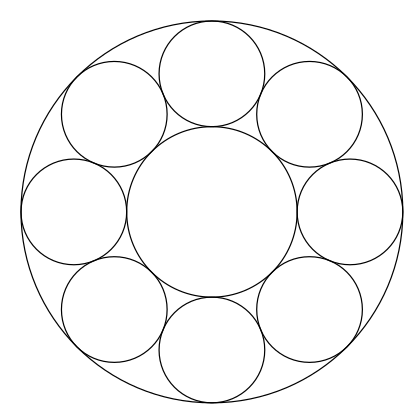

In [5]:
%%circlepack
seed 8
max_pack
disp -w -c

## 2. Colors and faces

Commands compose. Color the boundary circles (`b`) and interior circles (`i`),
then draw faces as well as circles (`disp -w -c -f`):

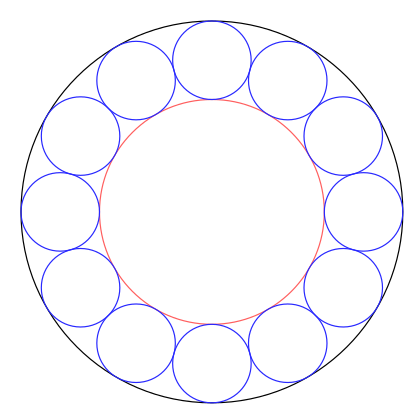

In [6]:
%%circlepack
seed 12
max_pack
color -c 20 b
color -c 180 i
disp -w -c -f

## 3. Geometry: a hyperbolic maximal packing

CirclePack works in euclidean, hyperbolic, and spherical geometry. Convert to
hyperbolic (`geom_to_h`) and lay out the maximal packing inside the unit disk:

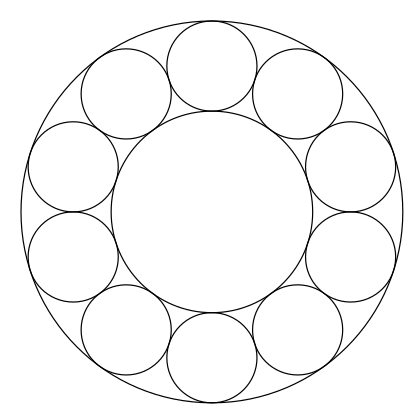

In [7]:
%%circlepack
seed 10
geom_to_h
max_pack
disp -w -c

## 4. Mixing in Python

Because `%%circlepack` runs on the **ordinary Python kernel**, normal Python
cells work right alongside CirclePack cells.

In [8]:
import math
sizes = [4, 6, 8, 12]
print("flower sizes:", sizes)
print("regular n-gon interior angle (deg):",
      [round(180 * (n - 2) / n, 1) for n in sizes])

flower sizes: [4, 6, 8, 12]
regular n-gon interior angle (deg): [90.0, 120.0, 135.0, 150.0]


### Driving CirclePack *from* Python

For loops, parameter sweeps, or feeding Python values into CirclePack, use the
`circlepack_client` module directly. Below we build several packings in a
Python loop and collect CirclePack's result codes (`cmd result: N`).

In [9]:
from circlepack_client import CirclePackClient

results = {}
with CirclePackClient(name="demo-python") as cp:
    for n in sizes:
        results[n] = cp.run(f"seed {n};max_pack")
results

TimeoutError: timed out

## 5. Scripts ⇄ notebooks

A CirclePack script (`.cps`) is essentially a notebook already — explanatory
text interleaved with commands. The converters in `cptools/` translate both
ways. Convert the bundled tutorial script into a notebook you can open:

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "cps2ipynb.py",
                "../scripts/First_script.cps", "First_script_demo.ipynb"],
               check=True)
print("wrote First_script_demo.ipynb — open it from the Jupyter file browser")

## 6. Save a session back to CirclePack

Everything you run here also appears in CirclePack's own **Command Terminal**
(*Advanced → Command Terminal*), where **Save as .cps** exports the whole
session as a runnable script. You can also convert any notebook back to a
script with `ipynb2cps.py`:

```
python ipynb2cps.py my_notebook.ipynb my_script.cps
```

## Troubleshooting

- **`could not connect …`** — CirclePack isn't running, or not on port 3736.
  Start it with `runCP`, then re-run `%circlepack connect`.
- **No image appears** — set `%circlepack packdir <CirclePack packings dir>`.
  Without it you still get the command's result code, just no picture.
- **Picture didn't change** — make sure the cell ends with a `disp …` command.
- **Where's my query text?** — query commands like `?rad 1` print in
  CirclePack's *own* window; the socket returns a result count, not message
  text, so it won't appear in the notebook.
- **One notebook at a time** — CirclePack serves a single socket client; the
  magic holds one connection for the whole session.